In [1]:
import seaborn as sns
from matplotlib import pyplot as plt
import matplotlib.cm as cm
import matplotlib
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D
plt.rcParams['svg.fonttype']='none'
plt.rcParams['font.family'] = 'Arial'

import pandas as pd
import numpy as np
import torch
from torch import nn
from torch.autograd.functional import jacobian
import pickle
from sklearn import preprocessing
import json
import os
from torchdiffeq import odeint
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
from scipy.stats import pearsonr, linregress, gaussian_kde, entropy
from joblib import Parallel, delayed

import scvelo as scv
import scanpy as sc
import anndata as ad

In [2]:
## 真实向量场
def F(point, sets = np.array([10, 10*1e-3, 2, 0.5])):
    alfa, alfa0, n, beta = sets
    p1, p2, p3, m1, m2, m3 = point

    dp1 = -beta * (p1 - m1)
    dp2 = -beta * (p2 - m2)
    dp3 = -beta * (p3 - m3)
    
    dm1 = -m1 + alfa / (1 + p3 ** n) + alfa0
    dm2 = -m2 + alfa / (1 + p1 ** n) + alfa0
    dm3 = -m3 + alfa / (1 + p2 ** n) + alfa0

    return np.array([dp1, dp2, dp3, dm1, dm2, dm3])

In [3]:
class FullyConnected(nn.Module):
    def __init__(self):
        super(FullyConnected, self).__init__()

        self.layer1 = nn.Sequential(
            nn.Linear(in_features=6, out_features=32, bias=True),
            nn.ELU())

        self.layer2 = nn.Sequential(
            nn.Linear(in_features=32, out_features=32, bias=True),
            nn.BatchNorm1d(32),
            nn.ELU())

        self.layer4 = nn.Sequential(
            nn.Linear(in_features=32, out_features=6, bias=True)
            )

    def forward(self, t, x):
        fc1 = self.layer1(x)
        fc2 = self.layer2(fc1)
        output = self.layer4(fc2)
#         return 0.286436 * output
        return 0.149676 * output

In [4]:
dynamics_learner = FullyConnected()

dynamics_learner.load_state_dict(torch.load('Parameters_saved1_5.pickle', map_location=torch.device('cpu')))
dynamics_learner.eval()

FullyConnected(
  (layer1): Sequential(
    (0): Linear(in_features=6, out_features=32, bias=True)
    (1): ELU(alpha=1.0)
  )
  (layer2): Sequential(
    (0): Linear(in_features=32, out_features=32, bias=True)
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ELU(alpha=1.0)
  )
  (layer4): Sequential(
    (0): Linear(in_features=32, out_features=6, bias=True)
  )
)

In [5]:
## 读取数据
with open('data_with_phase.pickle', 'rb') as f:
    adata = pickle.load(f)
adata.shape

(5000, 7)

In [6]:
## 归一化细胞数据
np_data = adata[:, :-1]

# for i in range(np_data.shape[1]):
#     gene_data = np_data[:, i]
#     gene_data -= gene_data.min()
#     gene_data /= gene_data.max()
#     np_data[:, i] = gene_data
np_data.shape

(5000, 6)

In [7]:
th=adata[:,-1]
minima = min(th)
maxima = max(th)
norm = matplotlib.colors.Normalize(vmin=minima, vmax=maxima)
mapper = cm.ScalarMappable(norm=norm, cmap=cm.coolwarm)

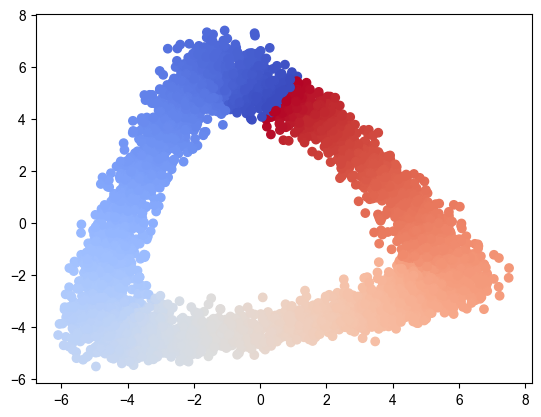

In [8]:
## PCA降维
pca = PCA(n_components=2)
pca.fit(np_data)
V = pca.components_.T
ratio = pca.explained_variance_ratio_
np_data_pca = (np_data - np.mean(np_data, axis=0)) @ V

plt.scatter(np_data_pca[:, 0], np_data_pca[:, 1],c=th,cmap=cm.coolwarm)

In [9]:
## 模拟一条轨迹(nODE)
def simulate_trajectory_nODE(step, sigma, dt):
    ## 随机选择一个初值
    i = np.random.randint(0, 5000)
    x0 = np_data[i, :].reshape(1, -1)
    yy = np.zeros((step, 6))
    xt = torch.as_tensor(x0, dtype=torch.float32)
    for j in range(step):
        yy[j, :] = xt.detach().numpy()
        f = dynamics_learner(0, xt)
        xt = xt + dt * f + torch.normal(mean=0, std=sigma, size=(6,))
    return yy

In [10]:
## 模拟一条轨迹(F)
def simulate_trajectory_F(step, sigma, dt):
    ## 随机选择一个初值
    i = np.random.randint(0, 5000)
    x0 = np_data[i, :]
    yy = np.zeros((step, 6))
    xt = x0
    for j in range(step):
        yy[j, :] = xt
        xt = xt + F(xt) * dt + np.random.normal(loc=0, scale=sigma, size=6)
    return yy

In [11]:
## 定义loss函数
def gaussian_kernel(source, target, kernel_mul=2.0, kernel_num=5, fix_sigma=None):
    """
    计算多核高斯核矩阵。
    :param source: 第一组样本 (n, d)
    :param target: 第二组样本 (m, d)
    :param kernel_mul: 用于控制不同核带宽的缩放因子
    :param kernel_num: 采用多少个不同带宽的核
    :param fix_sigma: 是否使用固定的 sigma
    :return: 返回核矩阵，大小为 (n+m, n+m)
    """
    total = np.vstack((source, target))  # 合并数据
    n_samples = total.shape[0]
    
    # 计算两两样本的欧几里得距离的平方
    L2_distance = np.sum(total**2, axis=1, keepdims=True) + np.sum(total**2, axis=1) - 2 * np.dot(total, total.T)
    L2_distance = np.maximum(L2_distance, 0)  # 避免数值误差导致的负值
    
    # 计算带宽 sigma
    if fix_sigma:
        bandwidth = fix_sigma
    else:
        bandwidth = np.sum(L2_distance) / (n_samples ** 2 - n_samples)
    
    bandwidth /= kernel_mul ** (kernel_num // 2)
    bandwidth_list = [bandwidth * (kernel_mul ** i) for i in range(kernel_num)]
    
    # 计算多核高斯核矩阵
    kernel_val = [np.exp(-L2_distance / bw) for bw in bandwidth_list]
    
    return sum(kernel_val)  # 返回最终的核矩阵

def mmd(source, target, kernel_mul=2.0, kernel_num=5, fix_sigma=None):
    """
    计算源分布和目标分布之间的最大均值差异（MMD）。
    
    参数：
    - source: NumPy 数组 (n, d) 代表源分布样本。
    - target: NumPy 数组 (m, d) 代表目标分布样本。
    - kernel_mul: 高斯核带宽的缩放因子（默认=2.0）。
    - kernel_num: 使用的高斯核数量（默认=5）。
    - fix_sigma: 是否使用固定标准差；若 None，则自适应计算（默认=None）。
    
    返回：
    - MMD 损失的平方根值，表示两个分布之间的距离。
    """
    n = source.shape[0]
    m = target.shape[0]
    
    kernels = gaussian_kernel(source, target,
                              kernel_mul=kernel_mul, kernel_num=kernel_num, fix_sigma=fix_sigma)
    
    XX = kernels[:n, :n]  # K_ss, 源分布内部的核矩阵
    YY = kernels[n:, n:]  # K_tt, 目标分布内部的核矩阵
    XY = kernels[:n, n:]  # K_st, 源分布到目标分布的核矩阵
    YX = kernels[n:, :n]  # K_ts, 目标分布到源分布的核矩阵
    
    XX = np.sum(XX) / (n * n)  # 归一化 K_ss
    XY = np.sum(XY) / (-n * m)  # 归一化 K_st
    YX = np.sum(YX) / (-m * n)  # 归一化 K_ts
    YY = np.sum(YY) / (m * m)   # 归一化 K_tt
    
    loss = XX + XY + YX + YY
    return np.sqrt(loss)

In [12]:
## 对真实F的随机模拟
    
# dt为步长
dt = 0.01
# D为扩散系数
D_values = [0.001, 0.003, 0.005, 0.007, 0.009]
# step为模拟步长
step = 10000
results = {} # 记录不同的D得到的轨迹
results_mmd = {} # 记录不同的D得到的mmd
for D in D_values:
    sigma = np.sqrt(2*dt*D)
    n = 1000
    ## 重复模拟n次
    all_yy = Parallel(n_jobs=10)(
        delayed(simulate_trajectory_F)(step, sigma, dt) 
        for _ in range(n))

    simulate_data = np.concatenate(all_yy, axis=0)
    results[D] = simulate_data

    ## 采样随机模拟的数据
    all_mmd = []
    for _ in range(50):
        random_indices = np.random.choice(simulate_data.shape[0], size=10000, replace=False)
        data = simulate_data[random_indices, :]
        loss = mmd(data, np_data)
        all_mmd.append(loss)

    results_mmd[D] = all_mmd

In [13]:
# ## 对nODE的随机模拟
# # dt为步长
# dt = 0.01
# # D为扩散系数
# D_values = [0.0005,0.001,0.005,0.01,0.02]
# # step为模拟步长
# step = 5000
# results = {} # 记录不同的D得到的轨迹
# results_mmd = {} # 记录不同的D得到的mmd
# for D in D_values:
#     sigma = np.sqrt(2*dt*D)
#     n = 1000
#     ## 重复模拟n次(并行计算)
#     all_yy = Parallel(n_jobs=10)(
#         delayed(simulate_trajectory_nODE)(step, sigma, dt) 
#         for _ in range(n))

#     simulate_data = np.concatenate(all_yy, axis=0)
#     results[D] = simulate_data
    
#     ## 采样随机模拟的数据
#     all_mmd = []
#     for _ in range(30):
#         random_indices = np.random.choice(simulate_data.shape[0], size=10000, replace=False)
#         data = simulate_data[random_indices, :]
#         loss = mmd(data, np_data)
#         all_mmd.append(loss)

#     results_mmd[D] = all_mmd

In [14]:
# 将字典转换为DataFrame
df = []
for D, mmd_values in results_mmd.items():
    for mmd in mmd_values:
        df.append((D, mmd))

df = pd.DataFrame(df, columns=['D', 'MMD'])
df['D'] = df['D'].astype(str)

median_mmd = df.groupby('D')['MMD'].median().reset_index()
median_mmd

,D,MMD
0,0.001,0.032301
1,0.003,0.024958
2,0.005,0.022802
3,0.007,0.024939
4,0.009,0.028899


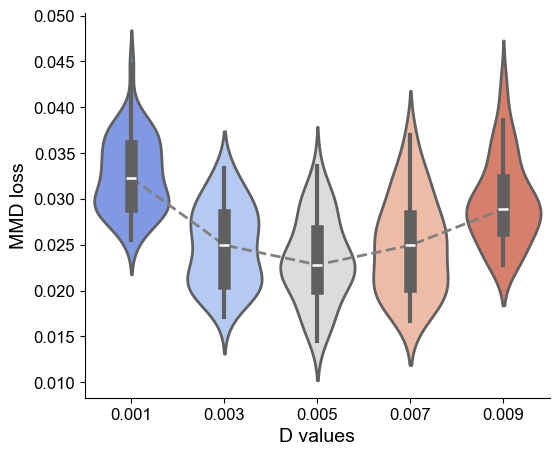

In [22]:
# 绘制小提琴图
plt.figure(figsize=(6, 5))

sns.lineplot(x='D', y='MMD', data=median_mmd, color='grey', linestyle='--', linewidth=2)
sns.violinplot(x='D', y='MMD', data=df, inner='box', linewidth=2, palette='coolwarm', scale='width')

plt.xlabel('D values', fontsize=14)
plt.ylabel('MMD loss', fontsize=14)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.savefig('./figures/D_estimate.svg', bbox_inches='tight', transparent=True)
plt.show()

Text(0.5, 1.0, 'trajectory_true')

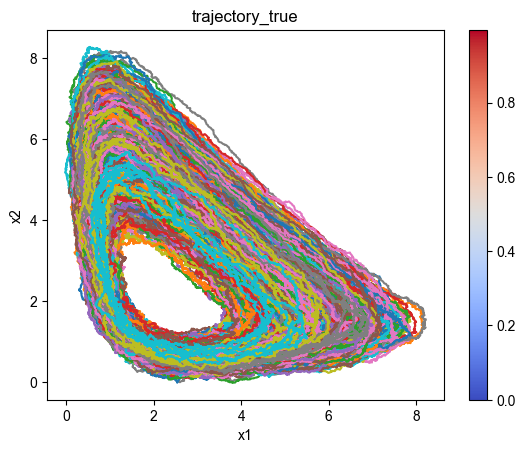

In [16]:
index1 = 0
index2 = 1
plt.scatter(np_data[:, index1], np_data[:, index2],c=th,cmap=cm.coolwarm)
for k in range(n):
    plt.plot(all_yy[k][:, index1], all_yy[k][:, index2])
plt.colorbar(mapper, ax=plt.gca())
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('trajectory_true')